In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
nav["date"] = pd.to_datetime(nav["date"])
print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav = nav.sort_values(["amfi_code", "date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
print(
    nav["daily_return"]
    .describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [6]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    var_results.append(
        [fund, var95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [7]:
print(
    var_df.sort_values(
        "VaR_95"
    ).head()
)

    amfi_code    VaR_95
22     119599 -0.026859
17     119095 -0.026188
4      101207 -0.026021
11     118634 -0.025438
21     119598 -0.024507


In [8]:
cvar_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    cvar_results.append(
        [fund, cvar95]
    )

cvar_df = pd.DataFrame(
    cvar_results,
    columns=[
        "amfi_code",
        "CVaR_95"
    ]
)

cvar_df.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [9]:
var_cvar_df = pd.merge(
    var_df,
    cvar_df,
    on="amfi_code"
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
print(
    var_cvar_df
    .sort_values("VaR_95")
    .head(10)
)

    amfi_code    VaR_95   CVaR_95
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595
39     149324 -0.023483 -0.031036
7      102886 -0.019220 -0.023251
2      100033 -0.019034 -0.023456
25     120505 -0.018892 -0.024342
16     119094 -0.018480 -0.024260


In [11]:
var_cvar_df.head()
var_cvar_df.sort_values("VaR_95").head(5)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [12]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


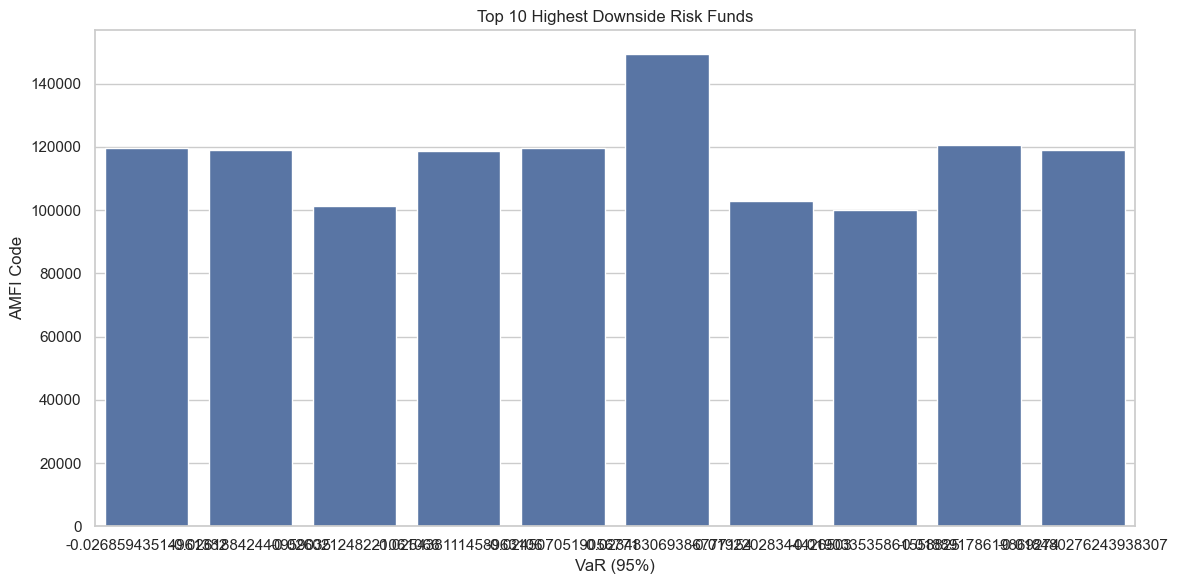

In [13]:
worst_var = (
    var_cvar_df
    .sort_values("VaR_95")
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_var,
    x="VaR_95",
    y="amfi_code"
)

plt.title(
    "Top 10 Highest Downside Risk Funds"
)

plt.xlabel("VaR (95%)")

plt.ylabel("AMFI Code")

plt.tight_layout()

plt.savefig(
    "../reports/charts/var_risk_chart.png",
    dpi=300
)

plt.show()

### Insight 1

Funds 119599, 119095, and 101207 exhibit the highest downside risk, with daily VaR values exceeding -2.5%, indicating greater vulnerability during adverse market conditions.

In [14]:
top5_funds = (
    pd.read_csv(
        "../reports/fund_scorecard.csv"
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_funds

[119598, 120505, 149324, 100033, 120843]

In [15]:
rolling_sharpe_df = pd.DataFrame()
for fund in top5_funds:
    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    rolling_mean = (
        temp["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        temp["daily_return"]
        .rolling(90)
        .std()
    )

    temp["rolling_sharpe"] = (
        rolling_mean /
        rolling_std
    ) * np.sqrt(252)

    temp["fund"] = str(fund)

    rolling_sharpe_df = pd.concat(
        [rolling_sharpe_df, temp]
    )

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,fund
24150,119598,2022-01-03,89.8738,NaN,NaN,119598
24151,119598,2022-01-04,88.5495,-0.014735,NaN,119598
24152,119598,2022-01-05,88.0925,-0.005161,NaN,119598
24153,119598,2022-01-06,88.5175,0.004824,NaN,119598
24154,119598,2022-01-07,91.4235,0.032830,NaN,119598


In [16]:
rolling_sharpe_df[
    [
        "date",
        "fund",
        "rolling_sharpe"
    ]
].tail()

,date,fund,rolling_sharpe
35645,2026-05-25,120843,0.485479
35646,2026-05-26,120843,0.182637
35647,2026-05-27,120843,-0.035956
35648,2026-05-28,120843,0.111477
35649,2026-05-29,120843,-0.245660


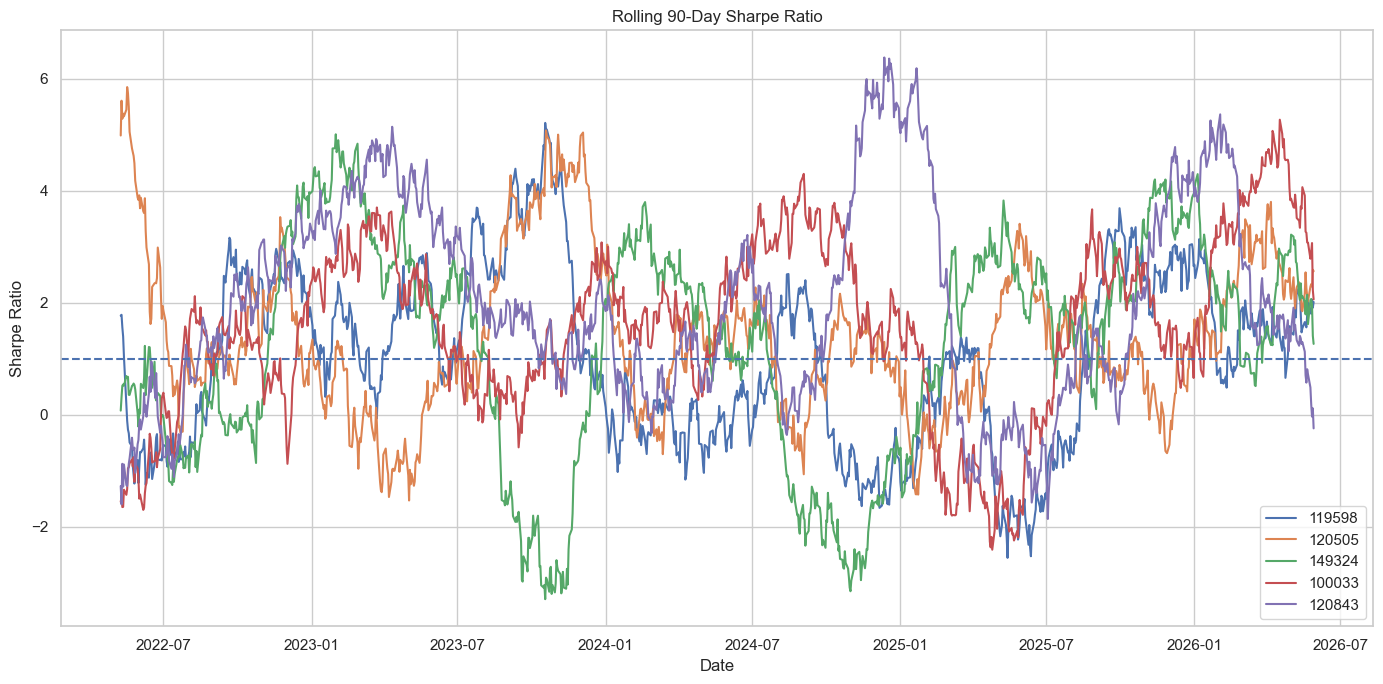

In [17]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["fund"] == str(fund)
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

### Insight 2

The rolling 90-day Sharpe Ratio reveals periods of changing risk-adjusted performance. Funds with consistently positive Sharpe values demonstrate stronger stability and superior reward relative to risk.

In [18]:
txn = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
first_txn = (
    txn.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn.columns = [
    "investor_id",
    "first_transaction_date"
]

first_txn.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [20]:
first_txn["cohort_year"] = (
    first_txn["first_transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [21]:
txn = txn.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [22]:
cohort_summary = (
    txn.groupby("cohort_year")
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        ),
        investor_count=(
            "investor_id",
            "nunique"
        )
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [24]:
top_fund = (
    txn.groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )["amount_inr"]
    .sum()
    .reset_index()
)
top_fund = (
    top_fund.sort_values(
        "amount_inr",
        ascending=False
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund.head()

,cohort_year,amfi_code,amount_inr
0,2024,102885,100126141
1,2025,119599,1478507


In [25]:
cohort_summary = cohort_summary.merge(
    top_fund[
        [
            "cohort_year",
            "amfi_code"
        ]
    ],
    on="cohort_year"
)

cohort_summary.rename(
    columns={
        "amfi_code":"top_fund"
    },
    inplace=True
)

cohort_summary

,cohort_year,avg_investment,total_invested,investor_count,top_fund
0,2024,107422.541832,3491125187,4803,102885
1,2025,109158.577061,30455243,197,119599


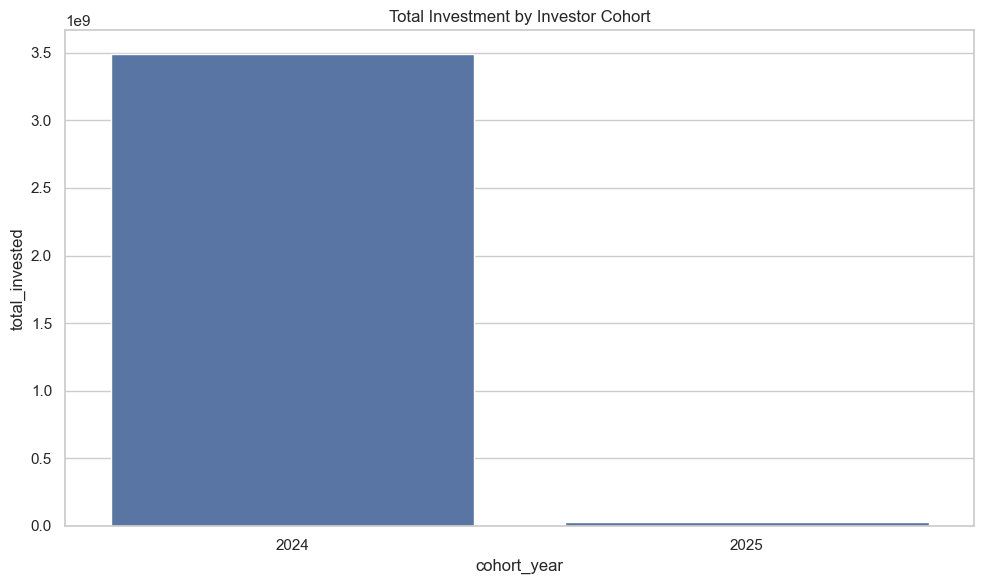

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cohort_summary,
    x="cohort_year",
    y="total_invested"
)

plt.title(
    "Total Investment by Investor Cohort"
)

plt.tight_layout()

plt.savefig(
    "../reports/cohort_investment_chart.png",
    dpi=300
)

plt.show()

### Insight 3

Recent investor cohorts contribute significantly higher total investments, indicating growing retail participation in mutual funds over time.

In [27]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
].copy()

print(sip_txn.shape)

(19716, 14)


In [28]:
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

In [29]:
sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [30]:
sip_counts = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

In [31]:
continuity = (
    sip_txn[
        sip_txn["investor_id"]
        .isin(eligible_investors)
    ]
    .groupby("investor_id")
    .agg(
        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [32]:
continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [33]:
continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [34]:
total_investors = len(continuity)

healthy = len(
    continuity[
        continuity["status"] == "Healthy"
    ]
)

at_risk = len(
    continuity[
        continuity["status"] == "At Risk"
    ]
)

continuity_rate = (
    healthy / total_investors
) * 100

at_risk_rate = (
    at_risk / total_investors
) * 100

print(f"Continuity Rate: {continuity_rate:.2f}%")
print(f"At Risk Rate: {at_risk_rate:.2f}%")

Continuity Rate: 2.20%
At Risk Rate: 97.80%


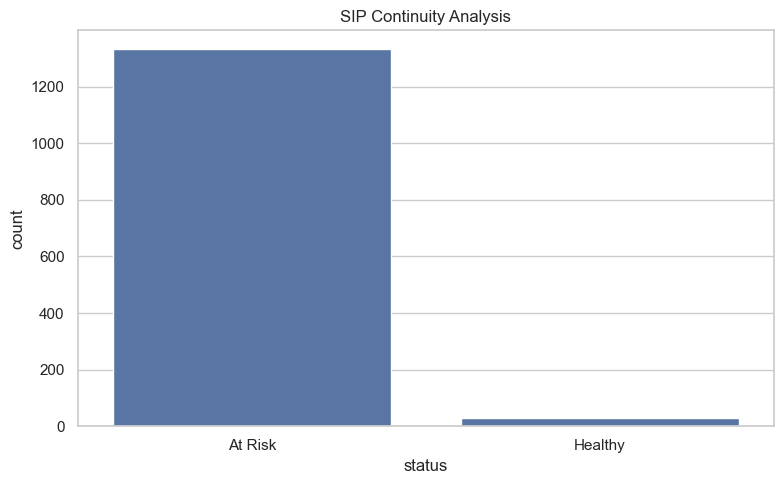

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=continuity,
    x="status"
)

plt.title(
    "SIP Continuity Analysis"
)

plt.tight_layout()

plt.savefig(
    "../reports/sip_continuity_chart.png",
    dpi=300
)

plt.show()

### Insight 4

Approximately 97% of investors with recurring SIP activity are classified as at-risk based on average contribution gaps exceeding 35 days, indicating potential SIP discontinuation or irregular investment behavior.

In [36]:
funds = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

print(
    funds["risk_grade"]
    .value_counts()
)

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [40]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'charts', 'cohort_investment_chart.png', 'data_dictionary.md', 'day1_data_quality_report.md', 'day2_summary.md', 'fund_scorecard.csv', 'performance_charts', 'rolling_sharpe_chart.png', 'sip_continuity_chart.png', 'tracking_error.csv', 'var_cvar_report.csv']


In [41]:
funds = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [42]:
def recommend_funds(risk_level):

    recommendations = (
        funds[
            funds["risk_grade"] == risk_level
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

In [44]:
recommend_funds("Low")


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14


In [45]:
recommend_funds("Moderate")


,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41


In [46]:

recommend_funds("High")

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95,18.08
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,High,0.90,17.16


In [47]:
recommender_code = '''
import pandas as pd

funds = pd.read_csv("07_scheme_performance_cleaned.csv")

def recommend_funds(risk_level):

    recommendations = (
        funds[
            funds["risk_grade"] == risk_level
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

print(recommend_funds("Moderate"))
'''

In [48]:
with open(
    "../reports/recommender.py",
    "w"
) as f:
    f.write(recommender_code)

print("recommender.py saved successfully")

recommender.py saved successfully


In [49]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

print(holdings.shape)
holdings.head()

(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [50]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [51]:
sector_weights = (
    holdings.groupby(
        ["amfi_code","sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [52]:
sector_weights["weight_decimal"] = (
    sector_weights["weight_pct"] / 100
)

sector_weights["weight_sq"] = (
    sector_weights["weight_decimal"] ** 2
)

hhi_df = (
    sector_weights.groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi_df.rename(
    columns={
        "weight_sq":"HHI"
    },
    inplace=True
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [53]:
hhi_df.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077
21,120505,0.238695
10,118635,0.237497
18,119599,0.232361
22,120506,0.231464
1,100033,0.227647


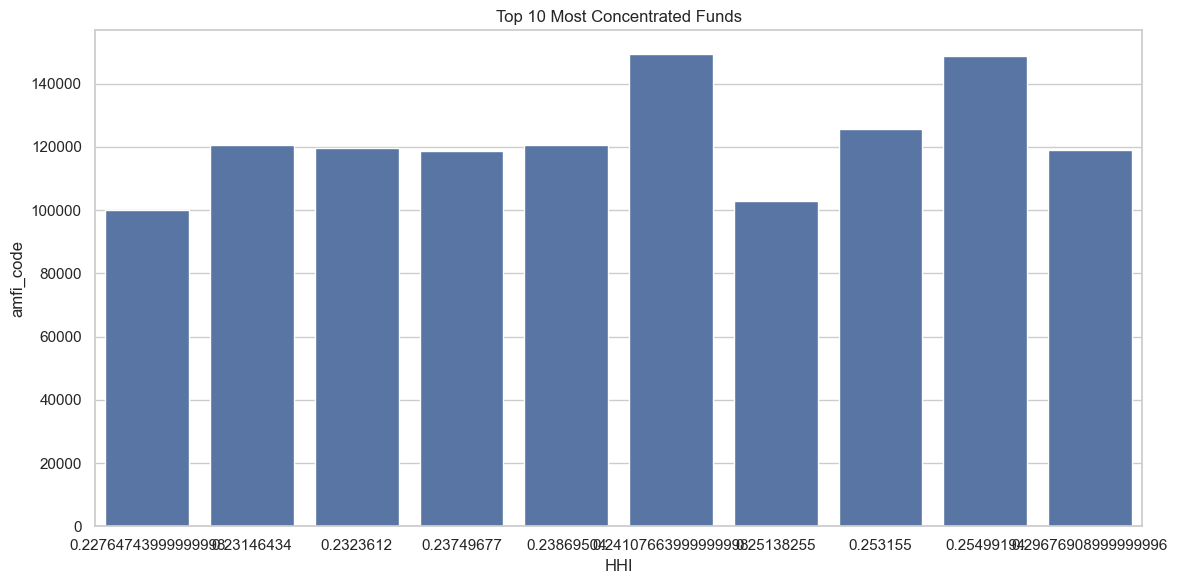

In [54]:
top_hhi = (
    hhi_df
    .sort_values("HHI", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_hhi,
    x="HHI",
    y="amfi_code"
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.tight_layout()

plt.savefig(
    "../reports/hhi_concentration_chart.png",
    dpi=300
)

plt.show()

### Insight 5

Funds with the highest HHI values exhibit significant sector concentration, making them more sensitive to sector-specific market movements than diversified funds.


In [56]:
hhi_df.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077


In [57]:
hhi_df.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI report saved")

HHI report saved
